<a href="https://colab.research.google.com/github/carolinajacoby/pharmacovigilance-scoping-review/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Configuration and import

In [ ]:
# Library installation

from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import numpy as np
from itertools import combinations

# Display configuration

plt.style.use('default')
sns.set_palette("husl")

# Constants and Settings

FILE_NAME = "/content/drive/MyDrive/Mestrado Carol/Revisão de Escopo/analysis/rawdata.xlsx"
COLUNA_ALGORITMOS = 'disproportionality_techniques'
DELIMITADOR = ','
EXCLUIR_TERMO = 'Not used'



# Auxiliary functions

In [ ]:
def count_algorithms(techniques_str, delimiter):
    """Conta o número de algoritmos em uma string, tratando NaNs e garantindo tipo string."""
    # Garante que techniques_str é uma string antes de limpar
    s = str(techniques_str).strip()

    if not s or s == EXCLUIR_TERMO:
        return 0

    # Divide pelo delimitador e remove espaços em branco
    techniques_list = [item.strip() for item in s.split(delimiter) if item.strip()]
    return len(techniques_list)

def padronizar_combos(techniques_str, delimiter):
    """Padroniza e ordena os algoritmos em uma string para contar combinações únicas."""
    s = str(techniques_str).strip()

    if not s or s == EXCLUIR_TERMO:
        return 'Nenhum ou Excluído'

    # Divide, limpa espaços (strip) e filtra strings vazias
    techniques_list = [item.strip() for item in s.split(delimiter) if item.strip()]

    # Ordena alfabeticamente
    techniques_list.sort()

    # Rejunta com separador padronizado
    return ' + '.join(techniques_list)

# Data loading

In [ ]:
# Create drive

drive.mount('/content/drive')
file_name = "/content/drive/MyDrive/Mestrado Carol/Revisão de Escopo/analysis/rawdata.xlsx"


Mounted at /content/drive


In [ ]:
# Data reading

df = pd.read_excel(file_name)
print(f" Data loaded: {len(df)} articles")
print(f" Columns: {list(df.columns)}")

# Show first lines
df.head(3)

 Data loaded: 162 articles
 Columns: ['article_id', 'year_publication', 'database', 'disproportionality_techniques', 'data_mining_algorithms_techiniques', 'other_techniques', 'drug_class', 'start_data_collection', 'end_data_collection', 'open_data', 'country', 'dataset_ made_ available', 'reference_vancouver']


,article_id,year_publication,database,disproportionality_techniques,data_mining_algorithms_techiniques,other_techniques,drug_class,start_data_collection,end_data_collection,open_data,country,dataset_ made_ available,reference_vancouver
0,1,2024,FAERS,"Information Component, Proportional Reporting ...",Not used,Chi-Square Test,"J01AA08 (Minocycline), J01BA01(Chloramphenicol...",2004,2022,no,India,yes,"Adusumilli PK, Begum F, George J. Antibiotics-..."
1,2,2024,FAERS,Reporting Odds Ratio,Not used,Chi-Square Test,"A10BA02 (Metformin), A10BK (SGLT-2 Inhibitors)",2013,2023,no,\nTürkiye,yes,"Aksoyalp ZŞ, Temel A. Urinary Tract Infections..."
2,3,2024,FAERS,"Empirical Bayes Geometric Mean, Information Co...",Not used,Descriptive Statistics,"N05BA01 (Diazepam), N05BA04 (Oxazepam), N05BA0...",1990,2020,no,Pakistan\n,no,"Ali Z, Goh KW, Ismail M, Ming LC. Association ..."


# Analysis: database

## Analysis 1: Distribution by Primary Data Source (Database)
Total records: 162
| Database                                                            |   Percentage (%) |   N |
|:--------------------------------------------------------------------|-----------------:|----:|
| FAERS                                                               |            83.33 | 135 |
| KIDS-KD/KAERS                                                       |             4.32 |   7 |
| OpenVigil                                                           |             3.09 |   5 |
| VigiBase                                                            |             1.85 |   3 |
| FAERS, JADER                                                        |             1.85 |   3 |
| JADER                                                               |             1.85 |   3 |
| VigiLyze                                                            |             0.62 |   1 |
| JADER, FAERS                                

/tmp/ipython-input-2213256838.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


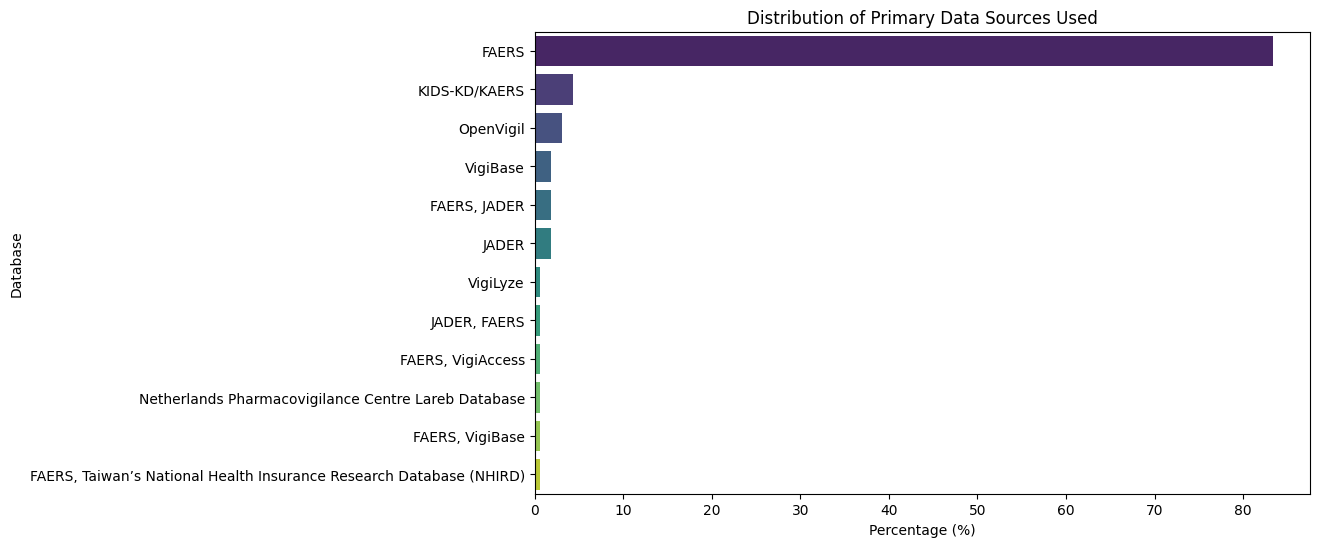

In [ ]:
print("## Analysis 1: Distribution by Primary Data Source (Database)")

# 1. Calculate frequency and percentage
database_analysis = df['database'].value_counts(normalize=True).mul(100).round(2).reset_index()
database_analysis.columns = ['Database', 'Percentage (%)']

# 2. Add the count for N
database_analysis['N'] = df['database'].value_counts().values

# 3. Sort and display
database_analysis = database_analysis.sort_values(by='N', ascending=False)
print(f"Total records: {len(df)}")
print(database_analysis.to_markdown(index=False))

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Percentage (%)',
    y='Database',
    data=database_analysis,
    palette="viridis"
)
plt.title('Distribution of Primary Data Sources Used')
plt.xlabel('Percentage (%)')
plt.show()

# Analysis: Drug Class and Drug

🏥 TOP 10 CLASSES TERAPÊUTICAS (NÍVEL ATC-2)
 1. L01 - 42 artigos ( 25.9%)
 2. N05 - 17 artigos ( 10.5%)
 3. L04 - 16 artigos (  9.9%)
 4. J01 - 13 artigos (  8.0%)
 5. A10 - 11 artigos (  6.8%)
 6. N06 - 11 artigos (  6.8%)
 7. N03 -  8 artigos (  4.9%)
 8. J05 -  8 artigos (  4.9%)
 9. N02 -  6 artigos (  3.7%)
10. D11 -  5 artigos (  3.1%)

💊 TOP 10 MEDICAMENTOS ESPECÍFICOS (NÍVEL ATC-5)
 1. L01FF03 -  8 artigos (  4.9%)
 2. L01FF01 -  8 artigos (  4.9%)
 3. L01FF02 -  8 artigos (  4.9%)
 4. L01FF05 -  8 artigos (  4.9%)
 5. L01FF04 -  7 artigos (  4.3%)
 6. L01FX04 -  6 artigos (  3.7%)
 7. N05AH04 -  5 artigos (  3.1%)
 8. D11AH05 -  4 artigos (  2.5%)
 9. M05BX04 -  4 artigos (  2.5%)
10. L01FX05 -  4 artigos (  2.5%)

📊 METODOLOGIA DA ANÁLISE
Total de artigos analisados: 162
Classes terapêuticas únicas (ATC-2): 44
Medicamentos únicos (ATC-5): 236
Artigos com múltiplos códigos ATC: 62


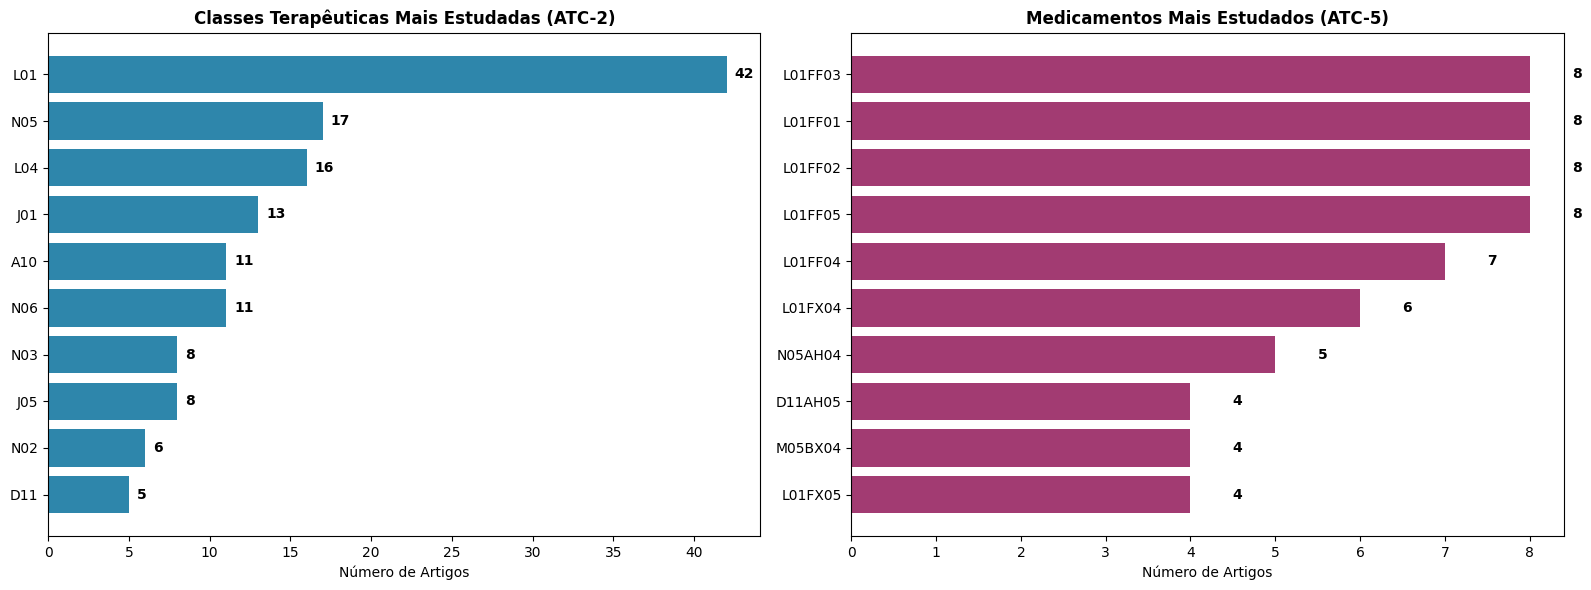

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Função melhorada para extrair ATC em diferentes níveis
def extract_atc_codes_multilevel(text):
    if pd.isna(text):
        return {'atc2': set(), 'atc3': set(), 'atc4': set(), 'atc5': set()}

    text = re.sub(r'\(.*?\)', '', str(text))
    parts = [p.strip() for p in text.split(',')]

    codes = []
    for p in parts:
        m = re.match(r'^([A-Z][0-9A-Z]{1,6})$', p)
        if m:
            codes.append(m.group(1))

    # Classificar por níveis ATC
    result = {'atc2': set(), 'atc3': set(), 'atc4': set(), 'atc5': set()}

    for code in codes:
        if len(code) >= 3:
            result['atc2'].add(code[:3])  # L01, N05, etc.
        if len(code) >= 4:
            result['atc3'].add(code[:4])  # L01F, N05A, etc.
        if len(code) >= 5:
            result['atc4'].add(code[:5])  # L01FF, N05AH, etc.
        if len(code) == 7:
            result['atc5'].add(code)      # L01FF01, etc.

    return result

# Contadores para diferentes níveis
counter_atc2 = Counter()  # Nível 2: Grupos farmacológicos (L01, N05)
counter_atc3 = Counter()  # Nível 3: Subgrupos farmacológicos (L01F, N05A)
counter_atc5 = Counter()  # Nível 5: Substâncias químicas (L01FF01)

# Processar TODOS os artigos
for drug_text in df['drug_class'].dropna():
    levels = extract_atc_codes_multilevel(drug_text)

    # Atualizar contadores - CADA ARTIGO CONTA UMA VEZ POR CATEGORIA
    counter_atc2.update(levels['atc2'])
    counter_atc3.update(levels['atc3'])
    counter_atc5.update(levels['atc5'])

n_articles = len(df)

# TOP 10 - Nível 2 (Melhor para revisão de escopo)
print("🏥 TOP 10 CLASSES TERAPÊUTICAS (NÍVEL ATC-2)")
print("=" * 50)
top_atc2 = counter_atc2.most_common(10)
for i, (atc_class, count) in enumerate(top_atc2, 1):
    percentage = (count / n_articles * 100)
    print(f"{i:2d}. {atc_class} - {count:2d} artigos ({percentage:5.1f}%)")

# TOP 10 - Nível 5 (Medicamentos específicos)
print("\n💊 TOP 10 MEDICAMENTOS ESPECÍFICOS (NÍVEL ATC-5)")
print("=" * 50)
top_atc5 = counter_atc5.most_common(10)
for i, (atc_code, count) in enumerate(top_atc5, 1):
    percentage = (count / n_articles * 100)
    print(f"{i:2d}. {atc_code} - {count:2d} artigos ({percentage:5.1f}%)")

# Estatísticas para metodologia
print(f"\n📊 METODOLOGIA DA ANÁLISE")
print("=" * 30)
print(f"Total de artigos analisados: {n_articles}")
print(f"Classes terapêuticas únicas (ATC-2): {len(counter_atc2)}")
print(f"Medicamentos únicos (ATC-5): {len(counter_atc5)}")
print(f"Artigos com múltiplos códigos ATC: {sum(1 for x in df['drug_class'].dropna() if ',' in str(x))}")

# Visualização comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 - Classes terapêuticas
classes, counts = zip(*top_atc2)
ax1.barh(classes, counts, color='#2E86AB')
ax1.set_xlabel('Número de Artigos')
ax1.set_title('Classes Terapêuticas Mais Estudadas (ATC-2)', fontweight='bold')
ax1.invert_yaxis()
for i, (cls, count) in enumerate(zip(classes, counts)):
    ax1.text(count + 0.5, i, f"{count}", va='center', fontweight='bold')

# Gráfico 2 - Medicamentos específicos
drugs, counts = zip(*top_atc5)
ax2.barh(drugs, counts, color='#A23B72')
ax2.set_xlabel('Número de Artigos')
ax2.set_title('Medicamentos Mais Estudados (ATC-5)', fontweight='bold')
ax2.invert_yaxis()
for i, (drug, count) in enumerate(zip(drugs, counts)):
    ax2.text(count + 0.5, i, f"{count}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Analysis: Open Data

In [ ]:
# Reproducibility analysis
print("\nOPEN DATA:")
print(f"   Yes: {df['open_data'].value_counts().get('yes', 0)} articles")
print(f"   No: {df['open_data'].value_counts().get('no', 0)} articles")

print("\nDATASET AVAILABLE:")
print(f"   Yes: {df['dataset_ made_ available'].value_counts().get('yes', 0)} articles")
print(f"   No: {df['dataset_ made_ available'].value_counts().get('no', 0)} articles")




OPEN DATA:
   Yes: 146 articles
   No: 16 articles

DATASET AVAILABLE:
   Yes: 2 articles
   No: 160 articles


# Analysis: Year of publication

## Analysis 3: Distribution by Year of Publication
Total records with year data: 162
|   Year |   Percentage (%) |   N |
|-------:|-----------------:|----:|
|   2015 |             0.62 |   1 |
|   2016 |             0.62 |   1 |
|   2017 |             1.85 |   3 |
|   2018 |             6.17 |  10 |
|   2019 |             2.47 |   4 |
|   2020 |             4.94 |   8 |
|   2021 |             7.41 |  12 |
|   2022 |             9.26 |  15 |
|   2023 |            12.96 |  21 |
|   2024 |            32.72 |  53 |
|   2025 |            20.99 |  34 |


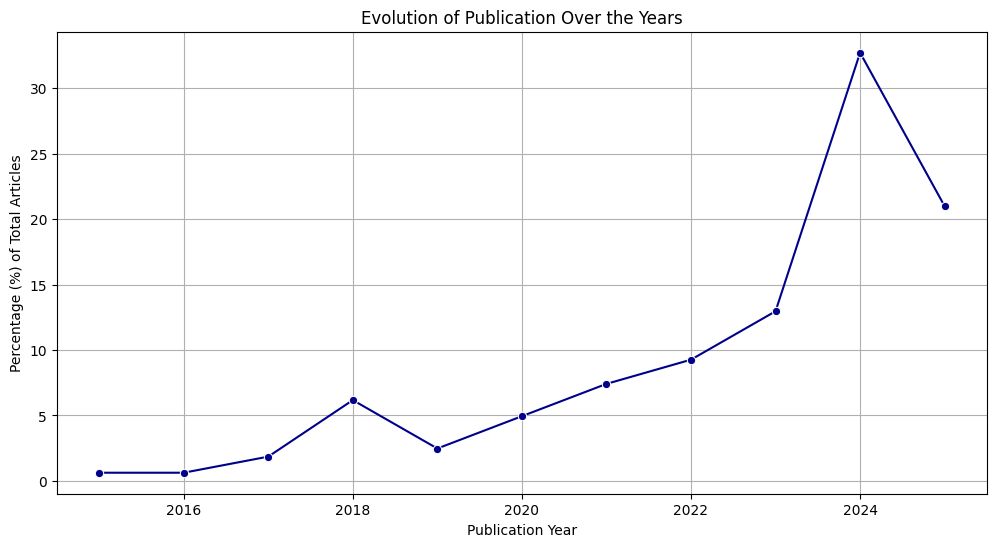

In [ ]:
print("## Analysis 3: Distribution by Year of Publication")

# 1. Ensure the column is numeric and filter NaNs
df_years = df[df['year_publication'].notna()].copy()
df_years['year_publication'] = df_years['year_publication'].astype(int)

# 2. Calculate frequency and percentage
year_analysis = df_years['year_publication'].value_counts(normalize=True).mul(100).round(2).reset_index()
year_analysis.columns = ['Year', 'Percentage (%)']

# 3. Add the count (N) and sort by year
year_analysis['N'] = df_years['year_publication'].value_counts().values
year_analysis = year_analysis.sort_values(by='Year', ascending=True)

print(f"Total records with year data: {len(df_years)}")
print(year_analysis.to_markdown(index=False))

# 4. Visualization (Line plot for time series)
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='Year',
    y='Percentage (%)',
    data=year_analysis,
    marker='o',
    color='darkblue'
)
plt.title('Evolution of Publication Over the Years')
plt.xlabel('Publication Year')
plt.ylabel('Percentage (%) of Total Articles')
plt.grid(True)
plt.show()

# Analysis: Data collection

In [ ]:
# Data Collection Periods Analysis
print(" DATA COLLECTION PERIODS ANALYSIS")
print("=" * 50)
print("EXPLORING DATA COLLECTION COLUMNS:")
print(f"start_data_collection sample: {df['start_data_collection'].head().tolist()}")
print(f"end_data_collection sample: {df['end_data_collection'].head().tolist()}")

# Check data types and unique values
print(f"\nData Types:")
print(f"start_data_collection: {df['start_data_collection'].dtype}")
print(f"end_data_collection: {df['end_data_collection'].dtype}")

print(f"\nUnique values in start_data_collection:")
print(df['start_data_collection'].dropna().unique()[:10])

print(f"\nUnique values in end_data_collection:")
print(df['end_data_collection'].dropna().unique()[:10])

 DATA COLLECTION PERIODS ANALYSIS
EXPLORING DATA COLLECTION COLUMNS:
start_data_collection sample: ['2004', '2013', '1990', '1978', '1968']
end_data_collection sample: [2022, 2023, 2020, 2021, 2018]

Data Types:
start_data_collection: object
end_data_collection: int64

Unique values in start_data_collection:
['2004' '2013' '1990' '1978' '1968' '1967' '2017' '2021' '2010' '2015']

Unique values in end_data_collection:
[2022 2023 2020 2021 2018 2024 2019 2017 2015 2012]


 DATA COLLECTION DURATION ANALYSIS
COLUMNS IN DATAFRAME:
['article_id', 'year_publication', 'database', 'disproportionality_techniques', 'data_mining_algorithms_techiniques', 'other_techniques', 'drug_class', 'start_data_collection', 'end_data_collection', 'open_data', 'country', 'dataset_ made_ available', 'reference_vancouver']

First few rows:
   article_id  year_publication database  \
0           1              2024    FAERS   
1           2              2024    FAERS   
2           3              2024    FAERS   

                       disproportionality_techniques  \
0  Information Component, Proportional Reporting ...   
1                               Reporting Odds Ratio   
2  Empirical Bayes Geometric Mean, Information Co...   

  data_mining_algorithms_techiniques        other_techniques  \
0                           Not used         Chi-Square Test   
1                           Not used         Chi-Square Test   
2                           Not used  Descriptive Statist

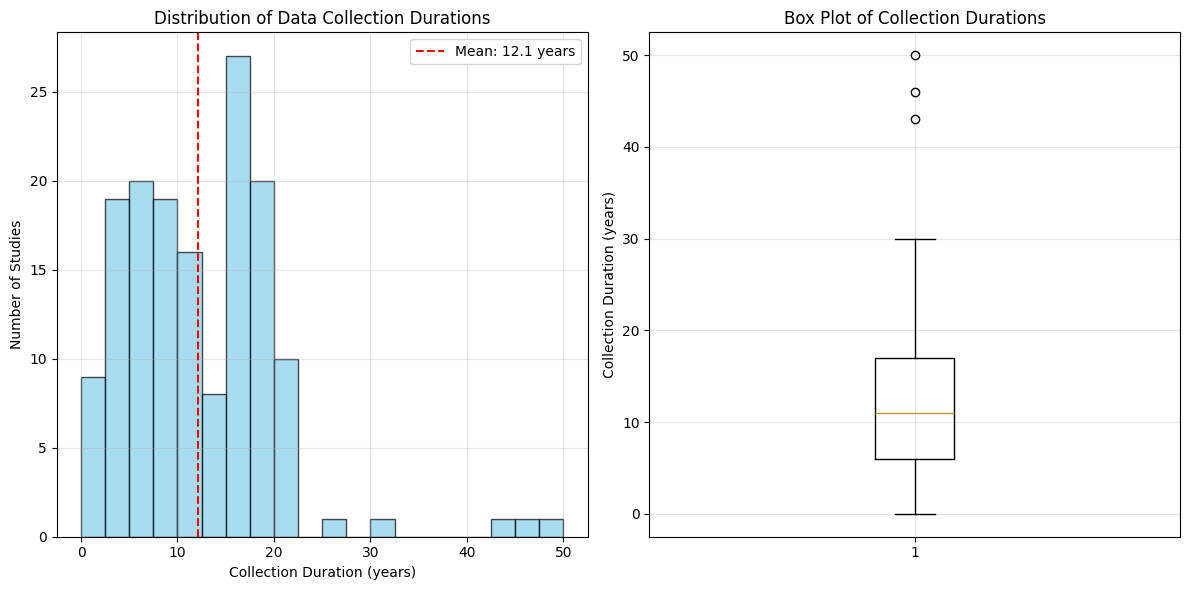


TOP 10 LONGEST DATA COLLECTION STUDIES:
------------------------------------------------------------
 1. article_id 5.0: 1968-2018 - 50.0 years
 2. article_id 25.0: 1968-2014 - 46.0 years
 3. article_id 4.0: 1978-2021 - 43.0 years
 4. article_id 3.0: 1990-2020 - 30.0 years
 5. article_id 43.0: 1988-2015 - 27.0 years
 6. article_id 113.0: 2002-2023 - 21.0 years
 7. article_id 51.0: 2004-2024 - 20.0 years
 8. article_id 59.0: 2004-2024 - 20.0 years
 9. article_id 75.0: 2004-2024 - 20.0 years
10. article_id 84.0: 2003-2023 - 20.0 years

TOP 10 SHORTEST DATA COLLECTION STUDIES:
------------------------------------------------------------
 1. article_id 104.0: 2023-2023 - 0.0 years
 2. article_id 101.0: 2015-2016 - 1.0 years
 3. article_id 35.0: 2022-2024 - 2.0 years
 4. article_id 78.0: 2020-2022 - 2.0 years
 5. article_id 80.0: 2020-2022 - 2.0 years
 6. article_id 119.0: 2021-2023 - 2.0 years
 7. article_id 133.0: 2019-2021 - 2.0 years
 8. article_id 134.0: 2022-2024 - 2.0 years
 9. arti

In [ ]:
# DATA COLLECTION DURATION ANALYSIS
print(" DATA COLLECTION DURATION ANALYSIS")
print("=" * 50)

# First, let's identify the correct column names
print("COLUMNS IN DATAFRAME:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
print(df.head(3))

# Find the ID column - look for common patterns
id_columns = [col for col in df.columns if any(word in col.lower() for word in ['id', 'article', 'study', 'pub'])]
print(f"\nPotential ID columns: {id_columns}")

if id_columns:
    id_column = id_columns[0]
    print(f"Using '{id_column}' as ID column")
else:
    # If no ID column found, create one using index
    id_column = 'generated_id'
    df[id_column] = range(1, len(df) + 1)
    print(f"No ID column found. Created '{id_column}' using dataframe index")

def clean_collection_year(value):
    """
    Clean and convert year values to integers
    Handles various data issues
    """
    if pd.isna(value):
        return None
    elif isinstance(value, str):
        # Remove text values like 'Database inception'
        if any(word in value.lower() for word in ['inception', 'unknown', 'not', 'na', 'n/a']):
            return None
        # Extract year from string
        try:
            # Find 4-digit years in string
            import re
            years = re.findall(r'\b\d{4}\b', value)
            if years:
                return int(years[0])
            else:
                return None
        except:
            return None
    elif isinstance(value, (int, float)):
        # Handle numeric values
        return int(value) if not pd.isna(value) else None
    else:
        return None

# Clean the data
df['start_year_clean'] = df['start_data_collection'].apply(clean_collection_year)
df['end_year_clean'] = df['end_data_collection'].apply(clean_collection_year)

print("\nDATA CLEANING RESULTS:")
print(f"Original start dates: {len(df)}")
print(f"Valid start years: {df['start_year_clean'].notna().sum()}")
print(f"Valid end years: {df['end_year_clean'].notna().sum()}")

# Filter only records with both start and end years
valid_duration_data = df.dropna(subset=['start_year_clean', 'end_year_clean']).copy()

print(f"\nRecords with both start and end years: {len(valid_duration_data)}")
print(f"Data coverage: {(len(valid_duration_data) / len(df) * 100):.1f}%")

# Calculate collection duration
valid_duration_data['collection_duration'] = (
    valid_duration_data['end_year_clean'] - valid_duration_data['start_year_clean']
)

# Filter reasonable durations (0 to 50 years)
reasonable_durations = valid_duration_data[
    (valid_duration_data['collection_duration'] >= 0) &
    (valid_duration_data['collection_duration'] <= 50)
]

print(f"Records with reasonable durations (0-50 years): {len(reasonable_durations)}")

# STATISTICAL ANALYSIS
print("\n" + "=" * 50)
print("COLLECTION DURATION STATISTICS")
print("=" * 50)

if len(reasonable_durations) > 0:
    duration_stats = reasonable_durations['collection_duration'].describe()

    print(f"Mean collection duration: {duration_stats['mean']:.1f} years")
    print(f"Median collection duration: {duration_stats['50%']:.1f} years")
    print(f"Minimum duration: {duration_stats['min']:.1f} years")
    print(f"Maximum duration: {duration_stats['max']:.1f} years")
    print(f"Standard deviation: {duration_stats['std']:.1f} years")

    # Additional statistics WITH ARTICLE IDs
    print(f"\nDISTRIBUTION ANALYSIS:")

    short_studies = reasonable_durations[reasonable_durations['collection_duration'] < 1]
    medium_studies = reasonable_durations[(reasonable_durations['collection_duration'] >= 1) & (reasonable_durations['collection_duration'] <= 5)]
    long_studies = reasonable_durations[reasonable_durations['collection_duration'] > 5]

    print(f"Short studies (< 1 year): {len(short_studies)}")
    if len(short_studies) > 0:
        print(f"  {id_column}: {', '.join(map(str, short_studies[id_column].tolist()))}")

    print(f"Medium studies (1-5 years): {len(medium_studies)}")
    if len(medium_studies) > 0:
        ids_list = medium_studies[id_column].head(10).tolist()
        print(f"  {id_column}: {', '.join(map(str, ids_list))}" +
              ("..." if len(medium_studies) > 10 else ""))

    print(f"Long studies (> 5 years): {len(long_studies)}")
    if len(long_studies) > 0:
        ids_list = long_studies[id_column].head(10).tolist()
        print(f"  {id_column}: {', '.join(map(str, ids_list))}" +
              ("..." if len(long_studies) > 10 else ""))

else:
    print("No valid duration data available for analysis")

# VISUALIZATION
if len(reasonable_durations) > 0:
    plt.figure(figsize=(12, 6))

    # Histogram of collection durations
    plt.subplot(1, 2, 1)
    plt.hist(reasonable_durations['collection_duration'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(reasonable_durations['collection_duration'].mean(), color='red', linestyle='--', label=f'Mean: {reasonable_durations["collection_duration"].mean():.1f} years')
    plt.xlabel('Collection Duration (years)')
    plt.ylabel('Number of Studies')
    plt.title('Distribution of Data Collection Durations')
    plt.legend()
    plt.grid(alpha=0.3)

    # Box plot
    plt.subplot(1, 2, 2)
    plt.boxplot(reasonable_durations['collection_duration'])
    plt.ylabel('Collection Duration (years)')
    plt.title('Box Plot of Collection Durations')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # TOP 10 LONGEST STUDIES WITH IDs
    print(f"\nTOP 10 LONGEST DATA COLLECTION STUDIES:")
    print("-" * 60)
    longest_studies = reasonable_durations.nlargest(10, 'collection_duration')[
        [id_column, 'start_year_clean', 'end_year_clean', 'collection_duration']
    ]
    for i, (idx, row) in enumerate(longest_studies.iterrows(), 1):
        print(f"{i:2d}. {id_column} {row[id_column]}: {int(row['start_year_clean'])}-{int(row['end_year_clean'])} - {row['collection_duration']} years")

    # TOP 10 SHORTEST STUDIES WITH IDs
    print(f"\nTOP 10 SHORTEST DATA COLLECTION STUDIES:")
    print("-" * 60)
    shortest_studies = reasonable_durations.nsmallest(10, 'collection_duration')[
        [id_column, 'start_year_clean', 'end_year_clean', 'collection_duration']
    ]
    for i, (idx, row) in enumerate(shortest_studies.iterrows(), 1):
        print(f"{i:2d}. {id_column} {row[id_column]}: {int(row['start_year_clean'])}-{int(row['end_year_clean'])} - {row['collection_duration']} years")

# DATA QUALITY ASSESSMENT WITH ARTICLE IDs
print(f"\n" + "=" * 50)
print("DATA QUALITY ASSESSMENT")
print("=" * 50)
print(f"Total studies in dataset: {len(df)}")
print(f"Studies with valid duration data: {len(reasonable_durations)}")
print(f"Data quality score: {(len(reasonable_durations) / len(df) * 100):.1f}%")

# Invalid durations with specific article IDs
invalid_durations = valid_duration_data[valid_duration_data['collection_duration'] < 0]
print(f"Invalid durations (end before start): {len(invalid_durations)}")
if len(invalid_durations) > 0:
    print(f"  {id_column} with invalid durations: {', '.join(map(str, invalid_durations[id_column].tolist()))}")

# Unrealistically long studies with IDs
too_long_durations = valid_duration_data[valid_duration_data['collection_duration'] > 50]
print(f"Unrealistically long (>50 years): {len(too_long_durations)}")
if len(too_long_durations) > 0:
    print(f"  {id_column} with >50 years duration: {', '.join(map(str, too_long_durations[id_column].tolist()))}")

# STUDIES WITH MISSING DATA
print(f"\nSTUDIES WITH MISSING DATA:")
missing_start = df[df['start_year_clean'].isna()]
missing_end = df[df['end_year_clean'].isna()]

print(f"Missing start dates: {len(missing_start)}")
if len(missing_start) > 0:
    print(f"  {id_column}: {', '.join(map(str, missing_start[id_column].tolist()))}")

print(f"Missing end dates: {len(missing_end)}")
if len(missing_end) > 0:
    print(f"  {id_column}: {', '.join(map(str, missing_end[id_column].tolist()))}")

# CREATE A SUMMARY TABLE FOR CITATIONS
print(f"\n" + "=" * 60)
print("SUMMARY TABLE FOR ARTICLE CITATIONS")
print("=" * 60)

# Create a comprehensive summary table
summary_table = reasonable_durations[[id_column, 'start_year_clean', 'end_year_clean', 'collection_duration']].copy()
summary_table = summary_table.rename(columns={
    id_column: 'Article_ID',
    'start_year_clean': 'Start_Year',
    'end_year_clean': 'End_Year',
    'collection_duration': 'Duration_Years'
})

print(f"\nFirst 20 articles with collection durations:")
print(summary_table.head(20).to_string(index=False))

# Save to CSV for easy reference
summary_table.to_csv('article_collection_durations.csv', index=False)
print(f"\nFull summary table saved to 'article_collection_durations.csv'")

# EXTREME CASES ANALYSIS
print(f"\n" + "=" * 60)
print("EXTREME CASES ANALYSIS")
print("=" * 60)

# Studies with very long duration (>30 years)
very_long_studies = reasonable_durations[reasonable_durations['collection_duration'] > 30]
print(f"Studies with >30 years duration: {len(very_long_studies)}")
if len(very_long_studies) > 0:
    print(f"{id_column}:")
    for article_id in very_long_studies[id_column].tolist():
        print(f"  - {article_id}")

# Recent long-term studies (ended after 2020 with >10 years duration)
recent_long_studies = reasonable_durations[
    (reasonable_durations['end_year_clean'] >= 2020) &
    (reasonable_durations['collection_duration'] > 10)
]
print(f"\nRecent long-term studies (ended after 2020, >10 years): {len(recent_long_studies)}")
if len(recent_long_studies) > 0:
    print(f"{id_column}:")
    for article_id in recent_long_studies[id_column].tolist():
        print(f"  - {article_id}")

# Analysis: Data mining algorithms

In [ ]:
# Analisando a coluna data_mining_algorithms_techiniques
ml_column = "data_mining_algorithms_techiniques"

# Primeiro, vamos ver todos os valores únicos
print("Valores únicos na coluna data_mining_algorithms_techiniques:")
print(df[ml_column].unique())
print("\n" + "="*60)

# Contagem de estudos que NÃO são "Not used"
ml_studies = df[df[ml_column] != 'Not used'].copy()
total_ml_studies = len(ml_studies)
print(f"Total de estudos com ML/outras técnicas: {total_ml_studies}/{len(df)} = {(total_ml_studies/len(df)*100):.1f}%")

# Função para extrair algoritmos da coluna
def extract_ml_algorithms(text):
    if pd.isna(text) or str(text).strip() in ['Not used', 'None', 'N/A']:
        return []

    text_str = str(text).strip()

    # Limpeza e extração
    algorithms = []

    # Dividir por vírgulas, ponto e vírgula, ou "and"
    parts = re.split(r'[,;]|\band\b', text_str)

    for part in parts:
        part = part.strip()
        if part and part not in ['', 'Not used']:
            # Remover parênteses e conteúdo dentro
            part = re.sub(r'\(.*?\)', '', part)
            part = part.strip()

            # Adicionar algoritmos principais
            if 'Association Rule Mining' in part:
                if 'Apriori' in part:
                    algorithms.append('Association Rule Mining (Apriori)')
                else:
                    algorithms.append('Association Rule Mining')
            elif 'Logistic Regression' in part:
                algorithms.append('Logistic Regression')
            elif 'Tree-based Scan Statistic' in part or 'TreeScan' in part:
                algorithms.append('Tree-based Scan Statistic')
            elif 'Network Analysis' in part or 'Hierarchical Clustering' in part:
                algorithms.append('Network/Hierarchical Clustering')
            elif 'K-means' in part or 'Hierarchical K-means' in part:
                algorithms.append('K-means/Hierarchical K-means')
            elif 'Spectral Clustering' in part:
                algorithms.append('Spectral Clustering')
            elif 'Gaussian Mixture Model' in part:
                algorithms.append('Gaussian Mixture Model (GMM)')
            elif 'Isolation Forest' in part:
                algorithms.append('Isolation Forest')
            elif 'Decision Tree' in part:
                algorithms.append('Decision Tree Analysis')
            elif 'Genetic Algorithm' in part:
                algorithms.append('Genetic Algorithm (GA)')
            elif 'Multilabel Classification' in part:
                algorithms.append('Multilabel Classification')
            elif 'Prediction Model-based' in part:
                algorithms.append('Prediction Model-based Algorithm')
            elif 'Bootstrap Resampling' in part:
                algorithms.append('Bootstrap Resampling')
            elif 'Concomitant Medication Analysis' in part:
                algorithms.append('Concomitant Medication Analysis')
            elif 'Molecular Data Integration' in part:
                algorithms.append('Molecular Data Integration')
            elif 'Pathway Enrichment Analysis' in part:
                algorithms.append('Pathway Enrichment Analysis')
            elif 'Protein-Protein Interaction' in part:
                algorithms.append('Protein-Protein Interaction (PPI) Analysis')
            elif 'Statistical Shrinkage' in part:
                algorithms.append('Statistical Shrinkage Transformation')
            elif 'Receptor Agonism/Antagonism' in part:
                algorithms.append('Receptor Agonism/Antagonism Analysis')
            elif part and len(part) > 3:
                algorithms.append(part)

    return list(set(algorithms))  # Remover duplicatas

# Aplicar extração
ml_studies['ml_algorithms'] = ml_studies[ml_column].apply(extract_ml_algorithms)
ml_studies['ml_count'] = ml_studies['ml_algorithms'].apply(len)

# Lista todos os estudos com ML
print("\nEstudos que usaram ML/outras técnicas:")
for idx, row in ml_studies.iterrows():
    print(f"ID {row['article_id']}: {row[ml_column]}")

print("\n" + "="*60)
print("ANÁLISE POR CATEGORIA")
print("="*60)

# Categorizar os estudos
categories = {
    'classification_regression': [],
    'association_rule_mining': [],
    'clustering': [],
    'other_computational': []
}

# IDs de cada categoria (baseado nos seus dados)
for idx, row in ml_studies.iterrows():
    article_id = row['article_id']
    ml_text = str(row[ml_column]).lower()

    # Verificar categorias
    if 'logistic regression' in ml_text or 'decision tree' in ml_text or 'multilabel classification' in ml_text or 'prediction model' in ml_text:
        categories['classification_regression'].append(article_id)

    if 'association rule' in ml_text or 'apriori' in ml_text:
        categories['association_rule_mining'].append(article_id)

    if 'cluster' in ml_text or 'k-means' in ml_text or 'hierarchical clustering' in ml_text or 'spectral' in ml_text or 'gaussian mixture' in ml_text:
        categories['clustering'].append(article_id)

    # Outros que não se encaixam nas categorias acima
    if (article_id not in categories['classification_regression'] and
        article_id not in categories['association_rule_mining'] and
        article_id not in categories['clustering']):
        categories['other_computational'].append(article_id)

# Contagens
total_studies = len(df)
print(f"\nTotal de estudos: {total_studies}")

print("\n1. CLASSIFICATION/REGRESSION:")
class_studies = categories['classification_regression']
print(f"   Número: {len(class_studies)} ({len(class_studies)/total_studies*100:.1f}% do total)")
print(f"   IDs: {sorted(class_studies)}")

# Detalhar algoritmos de classificação
print("\n   Algoritmos específicos:")
lr_count = sum(1 for id in class_studies if 'Logistic Regression' in str(df.loc[df['article_id'] == id, ml_column].iloc[0]))
print(f"   • Logistic Regression: {lr_count}/{len(class_studies)} ({lr_count/len(class_studies)*100:.1f}%)")

# Verificar outros algoritmos de classificação
for id in class_studies:
    ml_text = str(df.loc[df['article_id'] == id, ml_column].iloc[0])
    if 'Decision Tree' in ml_text:
        print(f"   • Decision Tree Analysis: 1 estudo (ID {id})")
    if 'Multilabel Classification' in ml_text:
        print(f"   • Multilabel Classification: 1 estudo (ID {id})")
    if 'Prediction Model-based' in ml_text:
        print(f"   • Prediction Model-based Algorithm: 1 estudo (ID {id})")

print("\n2. ASSOCIATION RULE MINING:")
arm_studies = categories['association_rule_mining']
print(f"   Número: {len(arm_studies)} ({len(arm_studies)/total_studies*100:.1f}% do total)")
print(f"   IDs: {sorted(arm_studies)}")
print(f"   • Todos usaram Apriori: {len(arm_studies)}/{len(arm_studies)} (100%)")

print("\n3. CLUSTERING:")
clust_studies = categories['clustering']
print(f"   Número: {len(clust_studies)} ({len(clust_studies)/total_studies*100:.1f}% do total)")
print(f"   IDs: {sorted(clust_studies)}")

print("\n4. OTHER COMPUTATIONAL ANALYSES:")
other_studies = categories['other_computational']
print(f"   Número: {len(other_studies)} ({len(other_studies)/total_studies*100:.1f}% do total)")
print(f"   IDs: {sorted(other_studies)}")

print("\n" + "="*60)
print("ESTUDOS SEM TÉCNICAS DE DESPROPORCIONALIDADE")
print("="*60)

# Estudos que usaram APENAS ML (sem técnicas de desproporcionalidade)
pure_ml_studies = []
for idx, row in df.iterrows():
    if row['Usage_Type'] == 'Not Used' and row[ml_column] != 'Not used':
        pure_ml_studies.append(row['article_id'])

print(f"Estudos com APENAS ML (sem técnicas de desproporcionalidade): {len(pure_ml_studies)}")
print(f"IDs: {pure_ml_studies}")
for id in pure_ml_studies:
    print(f"  ID {id}: {df.loc[df['article_id'] == id, ml_column].iloc[0]}")

Valores únicos na coluna data_mining_algorithms_techiniques:
['Not used' 'Association Rule Mining (ARM) – Apriori'
 'Tree-based Scan Statistic (TreeScan), Logistic Regression'
 'Network Analysis / Hierarchical Clustering Analysis'
 'Logistic Regression'
 'Concomitant Medication Analysis, Molecular Data Integration, Receptor Agonism/Antagonism Cohort Analysis'
 'Bootstrap Resampling, Logistic Regression, Prediction Model-based Algorithm'
 'Decision Tree Analysis, Genetic Algorithm (GA), Multilabel Classification, Target Adverse-Event (TAE) Profile Analysis'
 'KEGG Pathway Enrichment Analysis, Network Analysis / Hierarchical Clustering Analysis, Protein-Protein Interaction (PPI) Analysis'
 'Association Rule Mining (ARM) – Apriori, Logistic Regression'
 'Statistical Shrinkage Transformation'
 'K-means, Hierarchical K-means (HK-means), Spectral Clustering, Gaussian Mixture Model (GMM), Isolation Forest (iF), Extended Isolation Forest (eiF)']

Total de estudos com ML/outras técnicas: 20/162


General summary of algorithm usage.
           Category  Number of articles % of total
 Without algorithms                 142      87.7%
        1 algorithm                  13       8.0%
Multiple algorithms                   7       4.3%

Distribution of articles by number of algorithms
 Qtde de Algoritmos  Nº artigos    %
                  1          13 8.0%
                  2           2 1.2%
                  3           3 1.9%
                  4           1 0.6%
                  6           1 0.6%

Artigos que usam 1 algoritmos (8.0%):
ID 18 -> Association Rule Mining (Arm) Apriori
ID 30 -> Association Rule Mining (Arm) Apriori
ID 49 -> Network Analysis Hierarchical Clustering Analysis
ID 64 -> Logistic Regression
ID 65 -> Logistic Regression
ID 66 -> Logistic Regression
ID 71 -> Association Rule Mining (Arm) Apriori
ID 88 -> Logistic Regression
ID 98 -> Logistic Regression
ID 104 -> Logistic Regression
ID 114 -> Logistic Regression
ID 124 -> Statistical Shrinkage Transformat

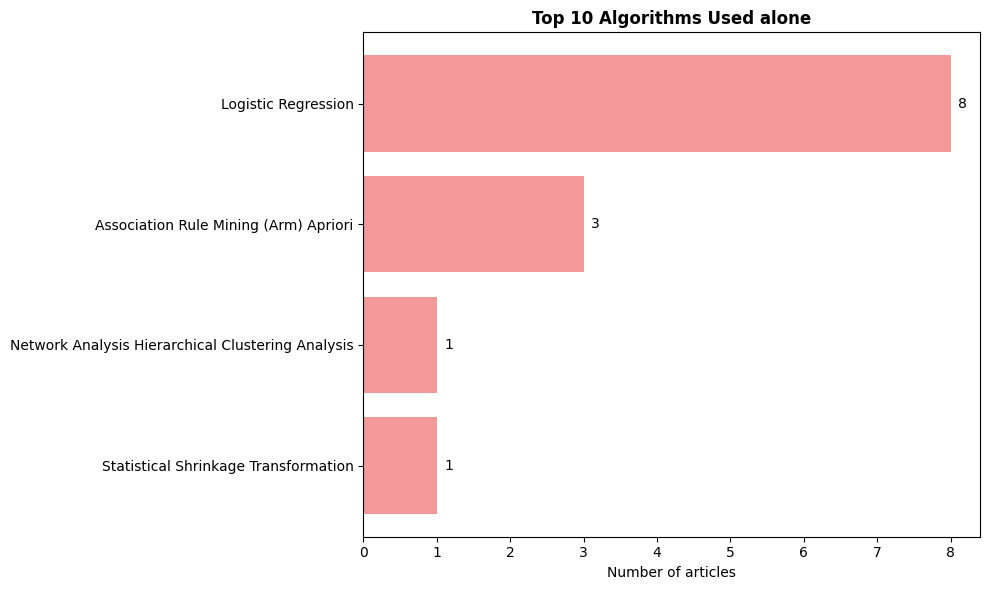

In [ ]:
# Main settings
id_column = "article_id"
algo_column = "data_mining_algorithms_techiniques"

# ------------------------------------------------------
# NORMALIZAÇÃO DOS NOMES DOS ALGORITMOS  (NOVO)
# ------------------------------------------------------
def normalize_algo_name(name):
    """Padroniza capitalização, espaços e estilo dos nomes."""
    name = name.strip()
    name = re.sub(r'\s+', ' ', name)      # reduz múltiplos espaços
    name = name.lower().title()           # capitaliza estilo Title Case
    return name


# ------------------------------------------------------
# CLEANING AND EXTRACTING ALGORITHMS
# ------------------------------------------------------

def extract_algorithms_final_slash(text):
    """Extrai algoritmos tratando corretamente os '/' e separadores"""
    if pd.isna(text):
        return []

    text_str = str(text).strip()
    if text_str.lower() in ['none', 'na', 'n/a', 'not applicable', 'not used', 'no algorithms', '']:
        return []

    # Ajuste de nomes compostos
    text_str = re.sub(r'Receptor Agonism/Antagonism', 'Receptor Agonism-Antagonism', text_str, flags=re.IGNORECASE)
    text_str = re.sub(r'Target Adverse-Event \(TAE\)', 'Target Adverse Event TAE', text_str, flags=re.IGNORECASE)

    parts = re.split(r'[,;|]', text_str)

    cleaned = []
    for part in parts:
        p = part.strip()

        # Transformar "word/word" em "word-word"
        p = re.sub(r'(\w+)/(\w+)', r'\1-\2', p)

        # Normalização de espaços
        p = ' '.join(p.split())

        # Limpeza de caracteres
        p = re.sub(r'[^\w\s\-\+\(\)]', '', p)

        if len(p) > 1:
            cleaned.append(p)

    # ------------------------------------------------------
    # NORMALIZAÇÃO FINAL DOS NOMES  (NOVO)
    # ------------------------------------------------------
    cleaned = [normalize_algo_name(p) for p in cleaned]

    return cleaned


# APLICA AO DATASET
df["algorithms_final_slash"] = df[algo_column].apply(extract_algorithms_final_slash)
df["algorithm_count_final_slash"] = df["algorithms_final_slash"].apply(len)


# ------------------------------------------------------
# GENERAL SUMMARY
# ------------------------------------------------------
total = len(df)
no_algos = df["algorithm_count_final_slash"].eq(0).sum()
one_algo = df["algorithm_count_final_slash"].eq(1).sum()
multi_algos = df["algorithm_count_final_slash"].gt(1).sum()

print("\n" + "="*70)
print("General summary of algorithm usage.")
print("="*70)
summary = pd.DataFrame({
    "Category": ["Without algorithms", "1 algorithm", "Multiple algorithms"],
    "Number of articles": [no_algos, one_algo, multi_algos],
    "% of total": [no_algos/total*100, one_algo/total*100, multi_algos/total*100]
})
print(summary.to_string(index=False, formatters={'% of total': '{:.1f}%'.format}))


# ------------------------------------------------------
# DISTRIBUTION OF ARTICLES BY NUMBER OF ALGORITHMS
# ------------------------------------------------------

print("\n" + "="*70)
print("Distribution of articles by number of algorithms")
print("="*70)

dist = (
    df[df["algorithm_count_final_slash"] > 0]
    .groupby("algorithm_count_final_slash")[id_column]
    .agg(list)
    .reset_index()
)
dist["Nº artigos"] = dist[id_column].apply(len)
dist["%"] = dist["Nº artigos"] / total * 100

print(
    dist[["algorithm_count_final_slash", "Nº artigos", "%"]]
    .rename(columns={"algorithm_count_final_slash": "Qtde de Algoritmos"})
    .to_string(index=False, formatters={"%": "{:.1f}%".format})
)

for _, row in dist.iterrows():
    n_algos = int(row["algorithm_count_final_slash"])
    pct = row["%"]
    print(f"\nArtigos que usam {n_algos} algoritmos ({pct:.1f}%):")
    for i in row[id_column]:
        algos = df.loc[df[id_column] == i, "algorithms_final_slash"].values[0]
        print(f"ID {i} -> {', '.join(algos)}")


# ------------------------------------------------------
# MOST FREQUENT COMBINATIONS
# ------------------------------------------------------

print("\n" + "="*70)
print("Most frequent combinations")
print("="*70)

multi = df[df["algorithm_count_final_slash"] > 1].copy()

# Cria string ordenada — evita duplicidade ROR+PRR vs PRR+ROR
multi["combo_str"] = multi["algorithms_final_slash"].apply(lambda x: " + ".join(sorted(x)))

combo_counts = multi["combo_str"].value_counts()

if combo_counts.empty:
    print("No multiple combination found..")
else:
    for combo, count in combo_counts.items():
        ids = multi[multi["combo_str"] == combo][id_column].tolist()
        pct = count / len(df) * 100
        n_algos = len(combo.split(" + "))
        print(f"\nArticles that use {n_algos} algorithms ({pct:.1f}%):")
        for i in ids:
            algos = df.loc[df[id_column] == i, "algorithms_final_slash"].values[0]

        print(f"ID {i} -> {', '.join(algos)}")


# ------------------------------------------------------
# MOST USED ALGORITHMS (OVERALL)
# ------------------------------------------------------

all_algos = [a for sub in df["algorithms_final_slash"] for a in sub]
algo_freq = pd.Series(Counter(all_algos)).sort_values(ascending=False)

print("\n" + "="*70)
print("Top 15 most used algorithms (overall)")
print("="*70)
print(algo_freq.head(15).to_frame("Number of articles").assign(
    **{"% of total": algo_freq.head(15)/len(df)*100}
).to_string(formatters={'% of total': '{:.1f}%'.format}))


# ------------------------------------------------------
# ALGORITHMS USED ALONE
# ------------------------------------------------------

single = df[df["algorithm_count_final_slash"] == 1]
solo_algos = single["algorithms_final_slash"].apply(lambda x: x[0]).value_counts()

print("\n" + "="*70)
print("Algorithms used alone")
print("="*70)
print(solo_algos.to_frame("Number of articles").assign(
    **{"% (between single)": solo_algos / len(single) * 100}
).to_string(formatters={'% (between single)': '{:.1f}%'.format}))



# PLOT TOP 10 SOLO


top_solo = solo_algos.head(10)

plt.figure(figsize=(10,6))
bars = plt.barh(top_solo.index[::-1], top_solo.values[::-1], color='lightcoral', alpha=0.8)
plt.xlabel('Number of articles')
plt.title('Top 10 Algorithms Used alone', fontweight='bold')

for i, v in enumerate(top_solo.values[::-1]):
    plt.text(v + 0.1, i, f'{v}', va='center')

plt.tight_layout()
plt.show()


# Analysis: Disproportionality Techniques

             COMPREHENSIVE ANALYSIS: DISPROPORTIONALITY TECHNIQUES

### 1. Overall Distribution (Solo vs. Combo) ###
Total Records Analyzed: 162
| Usage Type   |   Percentage (%) |
|:-------------|-----------------:|
| Combo        |            80.86 |
| Solo         |            17.9  |
| Not Used     |             1.23 |


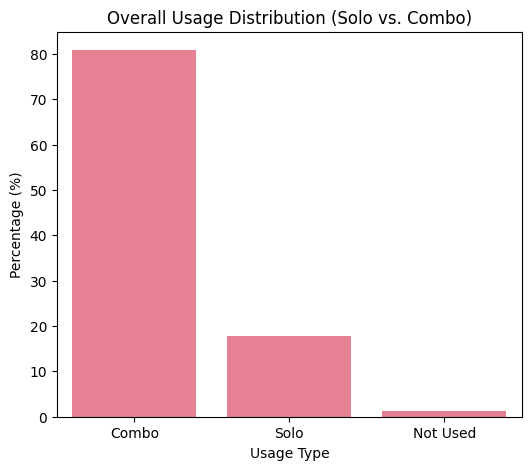


### 2. Detailed Solo Technique Analysis (Filtered) ###
Total Valid Solo Uses: 29
| Technique                              |   Quantity |   % of Filtered Solo Use |
|:---------------------------------------|-----------:|-------------------------:|
| Reporting Odds Ratio                   |         21 |                    72.41 |
| Proportional Reporting Ratio           |          4 |                    13.79 |
| Information Component                  |          2 |                     6.9  |
| Case-Only Odds Ratio (OR) Analysis     |          1 |                     3.45 |
| sROR (compressed reporting odds ratio) |          1 |                     3.45 |


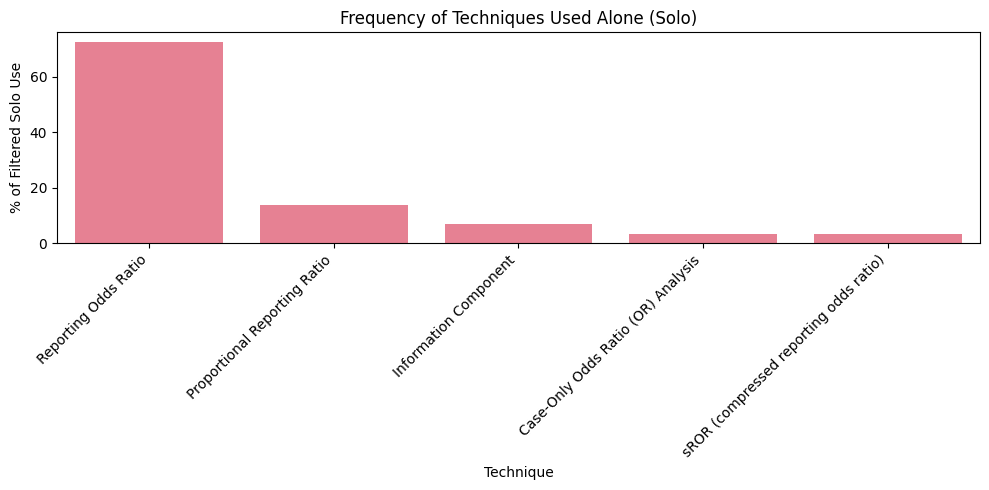


### 3. Detailed Combo Combinations Analysis (Top 10) ###
Total Unique Combinations: 36
Total Combo Records: 131
--- Top 10 Combinations ---
| Combination                                                                                                                                                      |   Quantity |   % of Total Combos |
|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------:|--------------------:|
| Bayesian Confidence Propagation Neural Network + Multi-item Gamma Poisson Shrinker + Proportional Reporting Ratio + Reporting Odds Ratio                         |         22 |               16.79 |
| Proportional Reporting Ratio + Reporting Odds Ratio                                                                                                              |         13 |                9.92 |
| Information Component + Reporting Odds Ratio             

/tmp/ipython-input-806464622.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-806464622.py:151: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


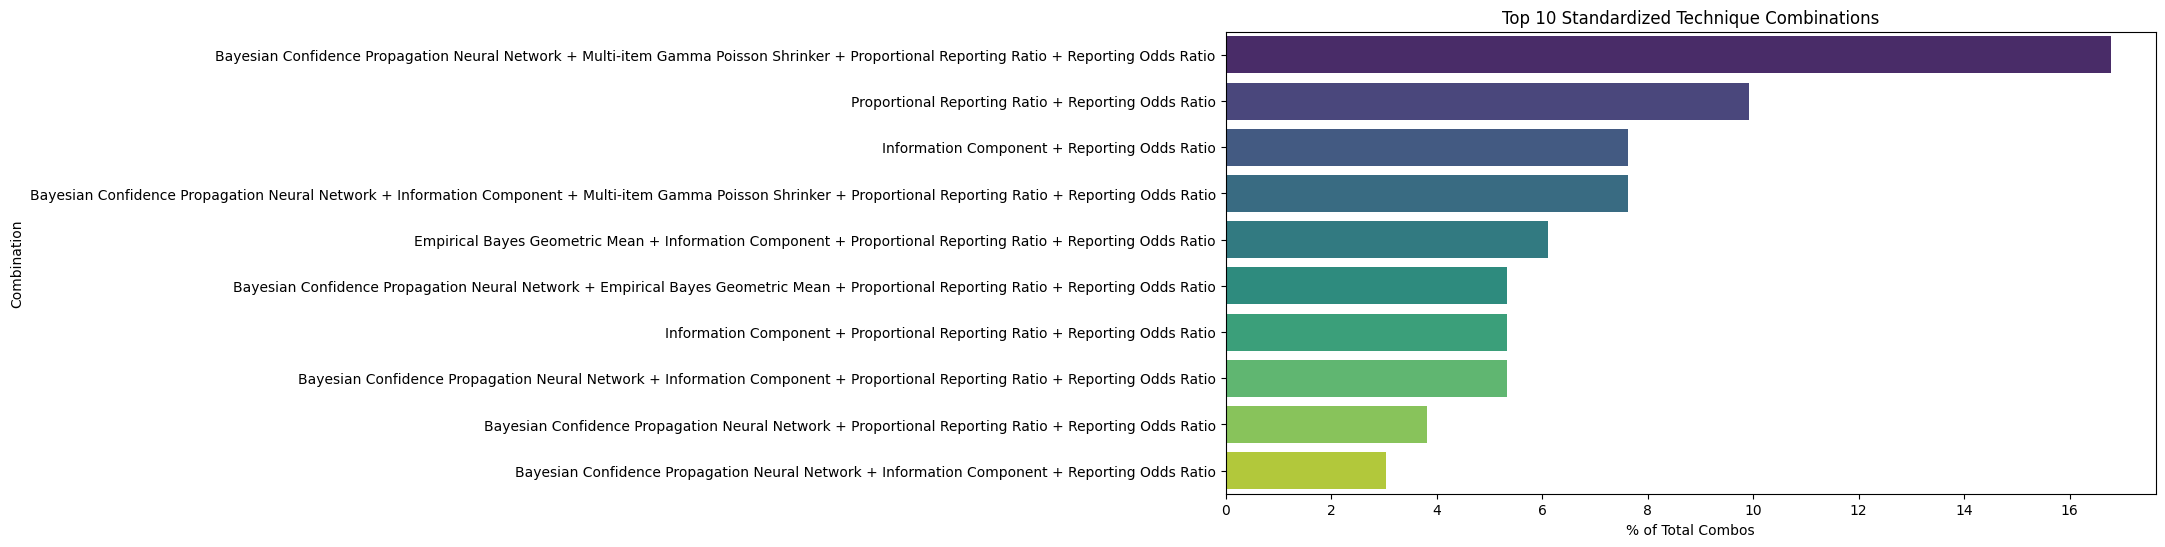


Top 15 most used techniques (overall)
                                                Number of articles % of total
Reporting Odds Ratio                                           142      87.7%
Proportional Reporting Ratio                                   103      63.6%
Bayesian Confidence Propagation Neural Network                  71      43.8%
Information Component                                           65      40.1%
Multi-item Gamma Poisson Shrinker                               38      23.5%
Empirical Bayes Geometric Mean                                  28      17.3%
MHRA Method                                                      7       4.3%
Case-non-case analysis                                           5       3.1%
Case-Only Odds Ratio (OR) Analysis                               5       3.1%
Shrinkage Measure Model                                          3       1.9%
Likelihood Ratio Test                                            2       1.2%
sROR (compressed reportin

In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------------------------------------------------------
# 1. CONFIGURATION AND PRE-PROCESSING
# ----------------------------------------------------------------------

# Main settings
id_column = "article_id"
# VARIABLE OF INTEREST
algo_column = "disproportionality_techniques"
EXCLUDE_TERM = 'None' # Term to exclude in Solo analysis

def extract_techniques_final_slash(text):
    """Extracts techniques, correctly handling separators, slashes, and compound terms."""
    if pd.isna(text):
        return []

    text_str = str(text).strip()
    if text_str.lower() in ['none', 'na', 'n/a', 'not applicable', 'not used', 'no algorithms', '']:
        return []

    # Adjusting compound names (kept from original user code)
    text_str = re.sub(r'Receptor Agonism/Antagonism', 'Receptor Agonism-Antagonism', text_str, flags=re.IGNORECASE)
    text_str = re.sub(r'Target Adverse-Event \(TAE\)', 'Target Adverse Event TAE', text_str, flags=re.IGNORECASE)

    # Split by common delimiters
    parts = re.split(r'[,;|]', text_str)

    # Individual cleaning
    cleaned = []
    for part in parts:
        p = part.strip()
        # Converts internal slashes (e.g., A/B) to hyphens (e.g., A-B)
        p = re.sub(r'(\w+)/(\w+)', r'\1-\2', p)
        p = ' '.join(p.split())
        # Removes special characters (except hyphens, parentheses, and math signs)
        p = re.sub(r'[^\w\s\-\+\(\)]', '', p)
        if len(p) > 1:
            cleaned.append(p)
    return cleaned


# Applying the cleaning functions
df["techniques_final_slash"] = df[algo_column].apply(extract_techniques_final_slash)
df["technique_count_final_slash"] = df["techniques_final_slash"].apply(len)

# Creating the Usage_Type variable (Solo, Combo, Not Used)
df['Usage_Type'] = df['technique_count_final_slash'].apply(
    lambda x: 'Solo' if x == 1 else ('Combo' if x > 1 else 'Not Used')
)


# ----------------------------------------------------------------------
# 2. COMPREHENSIVE ANALYSIS
# ----------------------------------------------------------------------

print("="*80)
print("             COMPREHENSIVE ANALYSIS: DISPROPORTIONALITY TECHNIQUES")
print("="*80)

# --- 2.1. Overall Distribution (Solo vs Combo) ---
print("\n### 1. Overall Distribution (Solo vs. Combo) ###")

total_records = len(df)
total_combo = len(df[df['Usage_Type'] == 'Combo'])
total_solo = len(df[df['Usage_Type'] == 'Solo'])

overall_distribution = df['Usage_Type'].value_counts(normalize=True).mul(100).round(2).reset_index()
overall_distribution.columns = ['Usage Type', 'Percentage (%)']
final_summary = overall_distribution[overall_distribution['Usage Type'].isin(['Solo', 'Combo', 'Not Used'])].copy()

print(f"Total Records Analyzed: {total_records}")
print(final_summary.to_markdown(index=False))

# Visualization
plt.figure(figsize=(6, 5))
sns.barplot(x='Usage Type', y='Percentage (%)', data=final_summary)
plt.title('Overall Usage Distribution (Solo vs. Combo)')
plt.show()


# --- 2.2. DETAILED SOLO ANALYSIS (Filtered - No 'Not Used') ---
print("\n### 2. Detailed Solo Technique Analysis (Filtered) ###")

df_solo = df[df['Usage_Type'] == 'Solo'].copy()
df_solo['Clean Technique'] = df_solo['techniques_final_slash'].apply(lambda x: x[0])
df_solo_filtered = df_solo[df_solo['Clean Technique'] != EXCLUDE_TERM].copy()

solo_counts_filtered = df_solo_filtered['Clean Technique'].value_counts()
solo_results = solo_counts_filtered.reset_index()
solo_results.columns = ['Technique', 'Quantity']

new_total_solo = solo_counts_filtered.sum()

solo_results['% of Filtered Solo Use'] = (solo_results['Quantity'] / new_total_solo) * 100
solo_results = solo_results.sort_values(by='Quantity', ascending=False).round(2)

print(f"Total Valid Solo Uses: {new_total_solo}")
print(solo_results.to_markdown(index=False))

# Visualization
if not solo_results.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Technique', y='% of Filtered Solo Use', data=solo_results)
    plt.title('Frequency of Techniques Used Alone (Solo)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# --- 2.3. DETAILED COMBO ANALYSIS (Standardized Combinations) ---
print("\n### 3. Detailed Combo Combinations Analysis (Top 10) ###")

df_combo = df[df['Usage_Type'] == 'Combo'].copy()

# Creating the Standardized Combination column (important for ensuring XY == YX)
df_combo['Standardized Combination'] = df_combo['techniques_final_slash'].apply(
    lambda x: " + ".join(sorted(x))
)

combo_counts = df_combo['Standardized Combination'].value_counts()
combo_results = combo_counts.reset_index()
combo_results.columns = ['Combination', 'Quantity']
total_combo_rows = len(df_combo)

combo_results['% of Total Combos'] = (
    combo_results['Quantity'] / total_combo_rows
) * 100
combo_results = combo_results.sort_values(by='Quantity', ascending=False).round(2)

print(f"Total Unique Combinations: {len(combo_results)}")
print(f"Total Combo Records: {total_combo_rows}")
print("--- Top 10 Combinations ---")
print(combo_results.head(10).to_markdown(index=False))

# Visualization of Top 10 Combos
if not combo_results.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x='% of Total Combos',
        y='Combination',
        data=combo_results.head(10),
        palette="viridis"
    )
    plt.title('Top 10 Standardized Technique Combinations')
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------
# 3. FREQUENCY AND DETAILED ANALYSIS
# ----------------------------------------------------------------------

# --- 3.1. Top 15 most used techniques (overall) ---
all_techs = [t for sub in df["techniques_final_slash"] for t in sub]
tech_freq = pd.Series(Counter(all_techs)).sort_values(ascending=False)

print("\n" + "="*70)
print("Top 15 most used techniques (overall)")
print("="*70)
print(tech_freq.head(15).to_frame("Number of articles").assign(
    **{"% of total": tech_freq.head(15)/total_records*100}
).to_string(formatters={'% of total': '{:.1f}%'.format}))


# --- 3.2. Techniques used alone ---
single = df[df["technique_count_final_slash"] == 1]
solo_techs = single["techniques_final_slash"].apply(lambda x: x[0]).value_counts()
print("\n" + "="*70)
print("Techniques used alone")
print("="*70)
if not single.empty:
    print(solo_techs.to_frame("Number of articles").assign(
        **{"% (between single)": solo_techs / len(single) * 100}
    ).to_string(formatters={'% (between single)': '{:.1f}%'.format}))
else:
     print("No single technique usage found.")

# --- 3.3. Detailed analysis by number of techniques ---
print("\n" + "="*70)
print("Distribution of articles by number of techniques")
print("="*70)

dist = (
    df[df["technique_count_final_slash"] > 0]
    .groupby("technique_count_final_slash")[id_column]
    .agg(list)
    .reset_index()
)
dist["Num articles"] = dist[id_column].apply(len)
dist["%"] = dist["Num articles"] / total_records * 100

print(
    dist[["technique_count_final_slash", "Num articles", "%"]]
    .rename(columns={"technique_count_final_slash": "Qty of Techniques"})
    .to_string(index=False, formatters={"%": "{:.1f}%".format})
)

for _, row in dist.iterrows():
    n_techs = int(row["technique_count_final_slash"])
    pct = row["%"]
    print(f"\nArticles using {n_techs} techniques ({pct:.1f}%):")
    for i in row[id_column]:
        techniques = df.loc[df[id_column] == i, "techniques_final_slash"].values[0]
        print(f"ID {i} -> {', '.join(techniques)}")


# --- 3.4. Most frequent combinations (Detailed list) ---
print("\n" + "="*70)
print("Most frequent combinations (Detailed list)")
print("="*70)

# Filter only articles with multiple techniques
multi = df[df["technique_count_final_slash"] > 1].copy()

# Creating the Standardized Combination column on the filtered DataFrame
multi['Standardized Combination'] = multi['techniques_final_slash'].apply(
    lambda x: " + ".join(sorted(x))
)

# Counting the combinations
combo_counts_detailed = multi["Standardized Combination"].value_counts()

if combo_counts_detailed.empty:
    print("No multiple combination found.")
else:
    for combo, count in combo_counts_detailed.items():
        ids = multi[multi["Standardized Combination"] == combo][id_column].tolist()
        pct = count / total_records * 100
        n_techs = len(combo.split(" + "))
        print(f"\nArticles using {n_techs} techniques ({pct:.1f}%):")
        for i in ids:
            techniques = df.loc[df[id_column] == i, "techniques_final_slash"].values[0]
            print(f"ID {i} -> {', '.join(techniques)}")

# Analysis: Other techniques


GENERAL SUMMARY OF TECHNIQUE USAGE (other_techniques)
           Category  Num articles % of total
 Without techniques            17      10.5%
        1 technique            61      37.7%
Multiple techniques            84      51.9%

Distribution of articles by number of techniques:
 Qty of Techniques  Num articles     %
                 1            61 37.7%
                 2            43 26.5%
                 3            24 14.8%
                 4             8  4.9%
                 5             5  3.1%
                 6             3  1.9%
                 7             1  0.6%

Articles using 1 techniques (37.7%):
ID 1 -> Chi-Square Test
ID 2 -> Chi-Square Test
ID 3 -> Descriptive Statistics
ID 11 -> Chi-Square Test
ID 15 -> Chi-Square Test
ID 20 -> Time-to-Onset (TTO) Time-to-Event Analysis
ID 25 -> Geographic and Demographic Analysis
ID 26 -> Descriptive Statistics
ID 27 -> Descriptive Statistics
ID 29 -> Descriptive Statistics
ID 31 -> Chi-Square Test
ID 34 -> Chi-Squa

/tmp/ipython-input-504593269.py:145: UserWarning: 
The palette list has fewer values (1) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


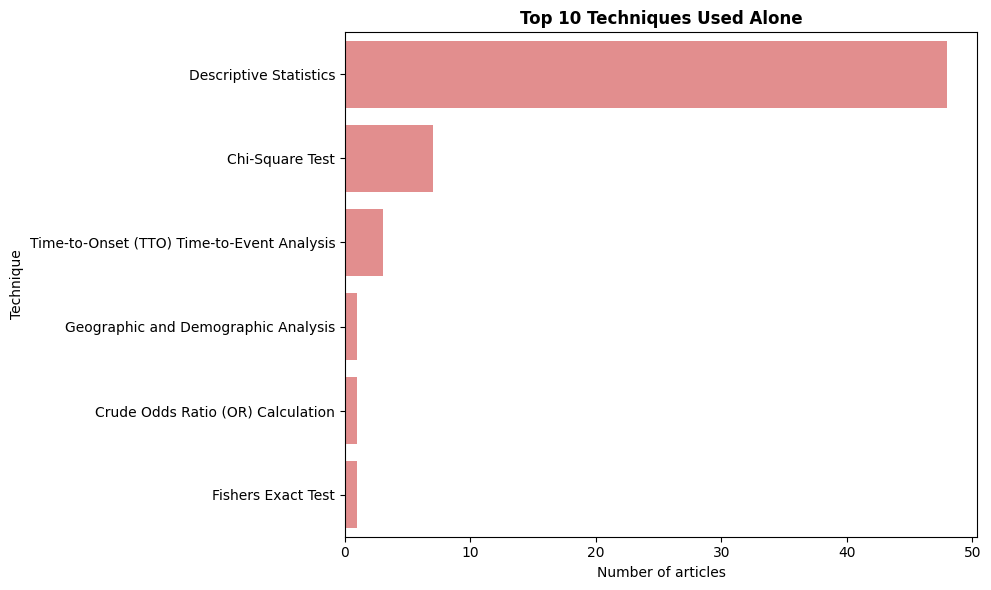

/tmp/ipython-input-504593269.py:165: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


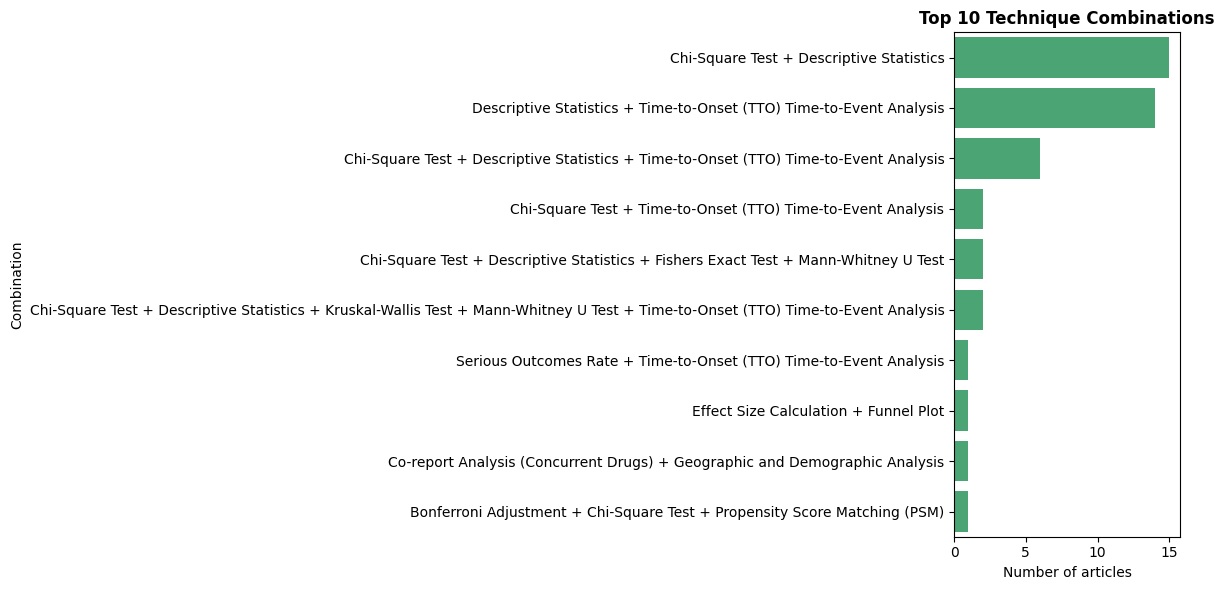

In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure your DataFrame 'df' is loaded in memory before execution.

# ============================================================
# SETTINGS
# ============================================================
id_column = "article_id"
tech_column = "other_techniques"  # target column

# ============================================================
# 1️⃣ Cleaning and Extraction
# ============================================================

def extract_techniques_final(text):
    """Extracts techniques from the 'other_techniques' column"""
    if pd.isna(text):
        return []

    text_str = str(text).strip()
    if text_str.lower() in ['none', 'na', 'n/a', 'not applicable', 'not used', 'no techniques', '']:
        return []

    # Custom corrections (if any)
    # Adapt as needed for specific patterns

    parts = re.split(r'[,;|]', text_str)

    cleaned = []
    for part in parts:
        p = part.strip()
        # Ensures internal slashes are not separated, using only hyphen as a word separator
        p = re.sub(r'(\w+)/(\w+)', r'\1-\2', p)
        p = re.sub(r'[^\w\s\-\+\(\)]', '', p)  # keeps letters, numbers, spaces, - + ()
        p = ' '.join(p.split()) # Removes multiple spaces
        if len(p) > 1:
            cleaned.append(p)
    return cleaned

# Apply extraction
df["other_techniques_clean"] = df[tech_column].apply(extract_techniques_final)
df["other_tech_count"] = df["other_techniques_clean"].apply(len)

# ============================================================
# 2️⃣ General Summary
# ============================================================

total = len(df)
no_tech = df["other_tech_count"].eq(0).sum()
one_tech = df["other_tech_count"].eq(1).sum()
multi_tech = df["other_tech_count"].gt(1).sum()

print("\n" + "="*70)
print("GENERAL SUMMARY OF TECHNIQUE USAGE (other_techniques)")
print("="*70)

summary = pd.DataFrame({
    "Category": ["Without techniques", "1 technique", "Multiple techniques"],
    "Num articles": [no_tech, one_tech, multi_tech],
    "% of total": [no_tech/total*100, one_tech/total*100, multi_tech/total*100]
})
print(summary.to_string(index=False, formatters={'% of total': '{:.1f}%'.format}))

# ============================================================
# 3️⃣ Distribution by number of techniques
# ============================================================

dist = (
    df[df["other_tech_count"] > 0]
    .groupby("other_tech_count")[id_column]
    .agg(list)
    .reset_index()
)
dist["Num articles"] = dist[id_column].apply(len)
dist["%"] = dist["Num articles"] / total * 100

print("\nDistribution of articles by number of techniques:")
print(
    dist.rename(columns={"other_tech_count": "Qty of Techniques"})\
        [["Qty of Techniques", "Num articles", "%"]].to_string(index=False, formatters={"%": "{:.1f}%".format})
)

for _, row in dist.iterrows():
    num_techs = int(row["other_tech_count"])
    pct = row["%"]
    print(f"\nArticles using {num_techs} techniques ({pct:.1f}%):")
    for i in row[id_column]:
        techs = df.loc[df[id_column] == i, "other_techniques_clean"].values[0]
        print(f"ID {i} -> {', '.join(techs)}")

# ============================================================
# 4️⃣ Most frequent combinations
# ============================================================

multi = df[df["other_tech_count"] > 1].copy()
# Standardizing combinations (e.g., A + B is the same as B + A)
multi["combo_str"] = multi["other_techniques_clean"].apply(lambda x: " + ".join(sorted(x)))
combo_counts = multi["combo_str"].value_counts()

print("\nMost frequent combinations of techniques (multiple):")
if combo_counts.empty:
    print("No multiple combination found.")
else:
    for combo, count in combo_counts.items():
        ids = multi[multi["combo_str"] == combo][id_column].tolist()
        pct = count / len(df) * 100
        num_techs = len(combo.split(" + "))
        print(f"\nArticles using {num_techs} techniques ({pct:.1f}%):")
        for i in ids:
            techs = df.loc[df[id_column] == i, "other_techniques_clean"].values[0]
            print(f"ID {i} -> {', '.join(techs)}")

# ============================================================
# 5️⃣ Most used techniques (overall and solo)
# ============================================================

all_techs = [t for sub in df["other_techniques_clean"] for t in sub]
tech_freq = pd.Series(Counter(all_techs)).sort_values(ascending=False)

print("\nTop 15 most used techniques (overall):")
print(tech_freq.head(15).to_frame("Num articles").assign(
    **{"% of total": tech_freq.head(15)/len(df)*100}
).to_string(formatters={'% of total': '{:.1f}%'.format}))

single = df[df["other_tech_count"] == 1]
solo_techs = single["other_techniques_clean"].apply(lambda x: x[0]).value_counts()
print("\nTechniques used alone:")
if len(single) > 0:
    print(solo_techs.to_frame("Num articles").assign(
        **{"% (among single)": solo_techs / len(single) * 100}
    ).to_string(formatters={'% (among single)': '{:.1f}%'.format}))
else:
    print("No technique was used alone.")

if not solo_techs.empty:
    top_solo = solo_techs.head(10)
    plt.figure(figsize=(10,6))

    # CORREÇÃO: Usamos 'y' para a barra e para 'hue' e definimos 'palette' como uma lista de cores
    sns.barplot(
        x=top_solo.values,
        y=top_solo.index,
        hue=top_solo.index,        # Adiciona hue para evitar o aviso de depreciação
        palette=['lightcoral'],    # Usa a cor como uma lista para ser tratada como paleta
        legend=False               # Remove a legenda desnecessária
    )

    plt.xlabel('Number of articles')
    plt.ylabel('Technique')
    plt.title('Top 10 Techniques Used Alone', fontweight='bold')
    plt.tight_layout()
    plt.show()

# 6.2 Most frequent combinations
if not combo_counts.empty:
    top_combos = combo_counts.head(10)
    plt.figure(figsize=(12, 6))

    # CORREÇÃO: Aplicando a mesma lógica para as combinações
    sns.barplot(
        x=top_combos.values,
        y=top_combos.index,
        hue=top_combos.index,
        palette=['mediumseagreen'], # Usa a cor como uma lista
        legend=False
    )

    plt.xlabel('Number of articles')
    plt.ylabel('Combination')
    plt.title('Top 10 Technique Combinations', fontweight='bold')
    plt.tight_layout()
    plt.show()